<a href="https://colab.research.google.com/github/grullaandrea-png/mushroom_classification_model_dervishi/blob/main/Mushrooms_final_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **MUSHROOMS** **CLASSIFICATION**

Andrea Grulla - 5407125

Mirko Dervishi - 5409240

# **Dataset**

source: https://www.kaggle.com/datasets/mdhasanahmad/12-mushroom-species-dataset/data

Overview:

This dataset contains 12,000 images of mushrooms, categorized into 12 distinct classes. It is perfectly balanced, with exactly 1,000 observations per class.

Why we chose it


*   Balanced Distribution: Prevents common biases found in real-world data.
*   Challenging Task: Mushrooms have high inter-class similarity and complex natural backgrounds.
*   Real-world Applications: It's an ideal foundation for developing practical AI tools.

Project Aims & Applications

*   Foraging Safety: Automated toxicity detection to prevent accidents.
*   Biodiversity Monitoring: Tracking fungal species in forest ecosystems.
*   Educational Tools: Spreading awareness about mycology and nature conservation.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/dataset_locale/
!unzip -q "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset_local/"

import os
print(os.listdir("/content/dataset_local/"))

['Data']


# **Exploratory Analysis**

Then we started our exploratory analysis retrieving all the class folder names from the dataset directory and computing the total number of classes, in order to confirm they have same dimension

In [6]:
import os

dataset_path = '/content/dataset_local/Data'

counts = {}

if os.path.exists(dataset_path):
    # all class folders
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for classe in classes:
        path_classe = os.path.join(dataset_path, classe)
        n_imagins = len(os.listdir(path_classe))
        counts[classe] = n_imagins
        print(f"Class: {classe:<20} | Imagins: {n_imagins}")

    print("-" * 40)
    print(f"Total imagins: {sum(counts.values())}")
else:
    print("Error: folder doesn't found")

Class: Inocybe              | Imagins: 1000
Class: Cortinarius          | Imagins: 1000
Class: Suillus              | Imagins: 1000
Class: Amanita              | Imagins: 1000
Class: Lactarius            | Imagins: 1000
Class: Agaricus             | Imagins: 1000
Class: Hygrocybe            | Imagins: 1000
Class: Entoloma             | Imagins: 1000
Class: Exidia               | Imagins: 1000
Class: Pluteus              | Imagins: 1000
Class: Russula              | Imagins: 1000
Class: Boletus              | Imagins: 1000
----------------------------------------
Total imagins: 12000


Plot an image for each class in order to show if there are some similar mushrooms and which are the main feature of each mushroom's type

Classes: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Exidia', 'Hygrocybe', 'Inocybe', 'Lactarius', 'Pluteus', 'Russula', 'Suillus']


<function matplotlib.pyplot.show(close=None, block=None)>

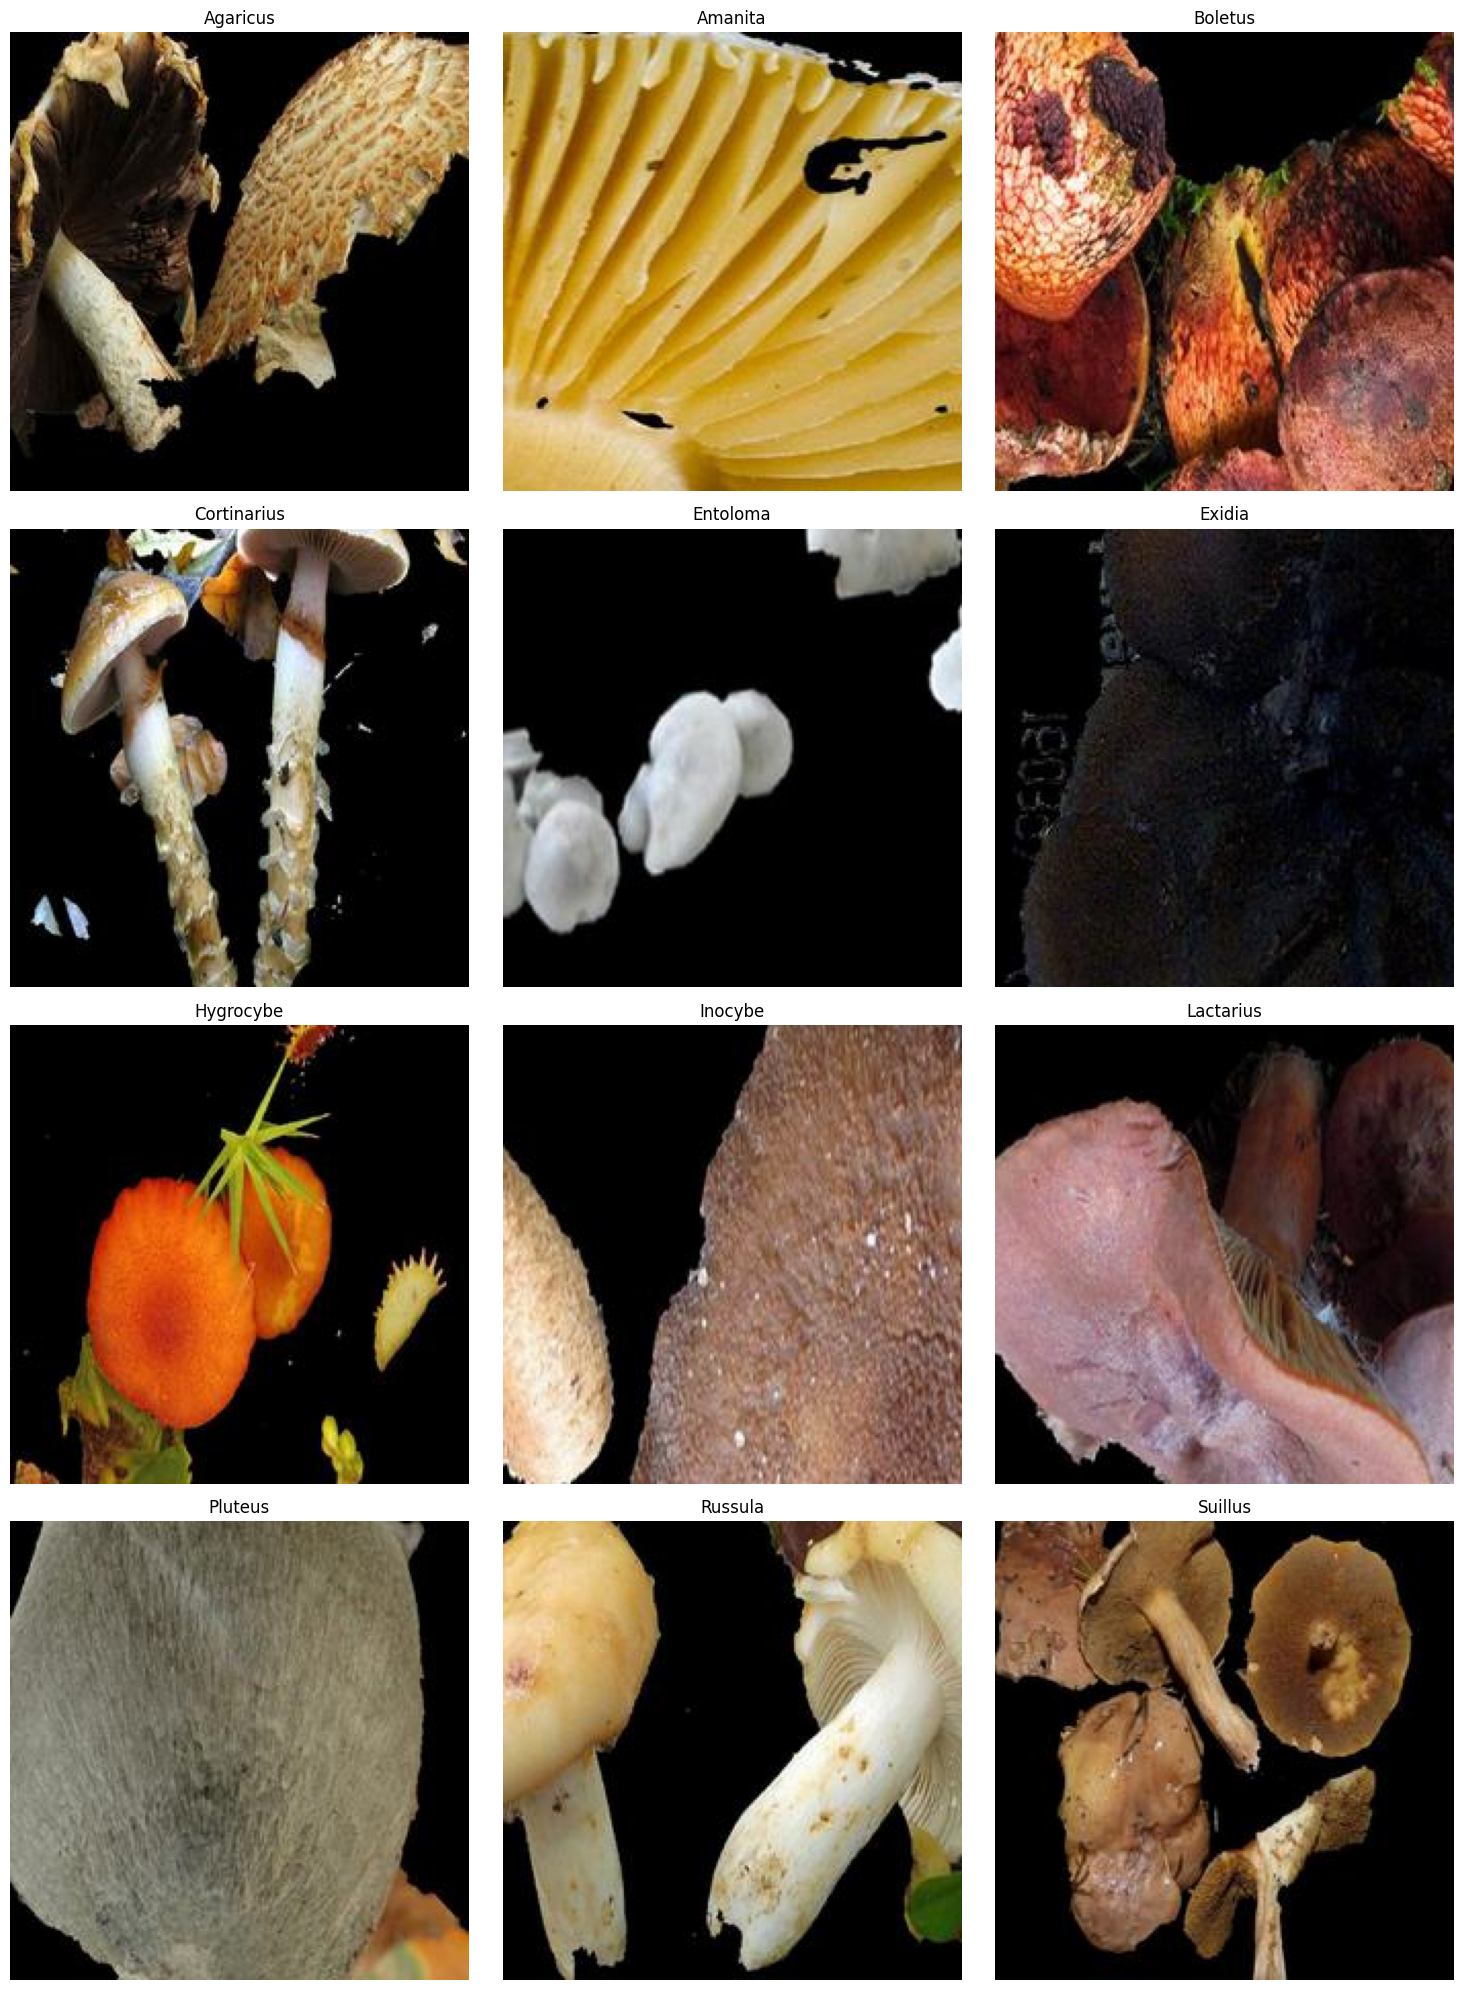

In [18]:
import os
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from PIL import Image
import math

full_dataset = ImageFolder(root='/content/dataset_local/Data')

class_names = full_dataset.classes
print(f"Classes: {class_names}")

num_classes = len(class_names)
cols = 3
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(15, 5 * rows))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)

    if os.path.isdir(class_folder):
        files = os.listdir(class_folder)
        if len(files) > 0:
            img_path = os.path.join(class_folder, files[0])

            img = Image.open(img_path)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

plt.tight_layout()
plt.show